In [14]:
# Check your Python version
from platform import python_version
python_version()

#!python -V
# pandas package needs to be added to the requirements.txt 's file 
%pip install pandas
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


# Character Limits: A Technical Case Study of Reverse-Engineering and  Fan-Translating Japanese Visual Novels on the Game Boy Advance

 ### Ian  Hunter [![orcid](https://orcid.org/sites/default/files/images/orcid_16x16.png)](https://orcid.org/0000-0003-3408-8138) 
Unaffiliated

[![cc-by](https://licensebuttons.net/l/by/4.0/88x31.png)](https://creativecommons.org/licenses/by/4.0/) 
©Ian . Published by De Gruyter in cooperation with the University of Luxembourg Centre for Contemporary and Digital History. This is an Open Access article distributed under the terms of the [Creative Commons Attribution License CC-BY](https://creativecommons.org/licenses/by/4.0/)


Reverse Engineering, Translation, Game Boy Advance, GBA, ROM Hacking, Visual Novels, Digital Preservation, Fanslation, Retro Gaming, Fanslation, Fan Translation

Throughout video game history, many titles have only been released regionally, whether for cultural, financial or other reasons. This paper examines the niche field of hobbyist or otherwise unofficial translation and repackaging of these games, making them accessible to audiences previously unable to engage with the media. By providing a technical case study of such a game's localization using reverse engineering techniques, this paper explores a side of the field that has seen little academic attention, discusses the complexities associated with the activity and highlights the crucial role of such grassroots initiatives in the preservation of digital culture.

## Introduction

Nintendo's Game Boy Advance (GBA) was launched in 2001 and ceased production in 2010 <cite id="bc3sn"><a href="#zotero%7C23690838%2FJM7QDKED">(Nintendo Co., Ltd., 2024)</a></cite>. Software sales continued for 2 more years before becoming a negligible amount in Nintendo's sales <cite id="rbwqm"><a href="#zotero%7C23690838%2FPU8S75C2">(Nintendo Co., 2015)</a></cite>. Since then, there have been three further generations of game consoles, which game development companies have moved onto, with significantly more processing and graphics capabilities.

However, a small niche of development continues on the GBA. A handful of indie developers have released original games for the console well after 2012  --- e.g., Goodboy Galaxy was funded on Kickstarter in 2025, promising a GBA release <cite id="p0uej"><a href="#zotero%7C23690838%2FIJCI3JAI">(Rik, 2021)</a></cite>. There is also a community of self-titled "ROM Hackers" (ROM here referring to the physical cartridges the games are stored on) who modify existing games to adapt, extend, and experiment with. 

A sub-group of these "ROM Hackers" are fan translators – or as they are more commonly known in the sphere "fanslators". Many GBA titles were released in only one language or a limited set of languages and never localized to other regions, excluding potential players. In [Table 1](table-gba-languages), we show the distribution of language support in the GBA games on the popular IGDB website. As can be seen, there is a sharp drop in non-English support, particularly outside Japanese and major European languages. With the discontinuation of the GBA ecosystem, most games are now unlikely to see an official new language release. By the fan translators unofficially translating these games, these games can reach a new audience. Despite the unlikelihood of official releases, GBA games are still under copyright in most jurisdictions, making much of the hobbyist work be of questionable legality. Initial legal cases such as the Nintendo vs GameGenie <cite id="eaul8"><a href="#zotero%7C23690838%2F4H2IPDGD">(U.S. Court of Appeals for the Ninth Circuit, 1992)</a></cite> "cheat cartridge" case have shown that the act of reverse engineering and modification of console code is itself not inherently illegal. Many other aspects of the law have not been tested in court, as companies typically have focussed on activities that can be seen as a percieved commercial conflict (e.g. creating seperate 'level' packs for an active console was deemed an illegal derivative in the MicroStar vs FormGen case <cite id="0zdfq"><a href="#zotero%7C23690838%2FS2Q4IPIQ">(U.S. Court of Appeals for the Ninth Circuit, 1992a)</a></cite>) and companies tend to prefer issuing takedown notices over costly legal battles (Such as the takedown request of the Metroid II remake project <cite id="zbimi"><a href="#zotero%7C23690838%2FU6DWCJ4M">(Machkovech, 2016)</a></cite>).

Despite the focus on protecting active commercial interests, even during the GBA's lifetime, several bootleg copies of popular games have been sold with unofficial (and often questionable, as seen in [Figure 1](#figure-bootleg)) translations. Unlike the majority of the ROM-hacking community, which generally operates on a non-profit basis, these physical counterfeits represented a direct trademark and copyright violation that Nintendo actively pursued through coordinated seizures with government organizations. The correspondence between Nintendo and the International Intellectual Property Alliance (IIPA) <cite id="47nko"><a href="#zotero%7C23690838%2FV4EQ2TW8">(Nintendo of America Inc., 2008)</a></cite> goes into great detail about the high volume of counterfeit cartridges, difficulties with differences in IP law and enforcement of such in other countries, and a set of recommended trade monitoring actions. These cartridges often included non-modified games that were illegally manufactured.

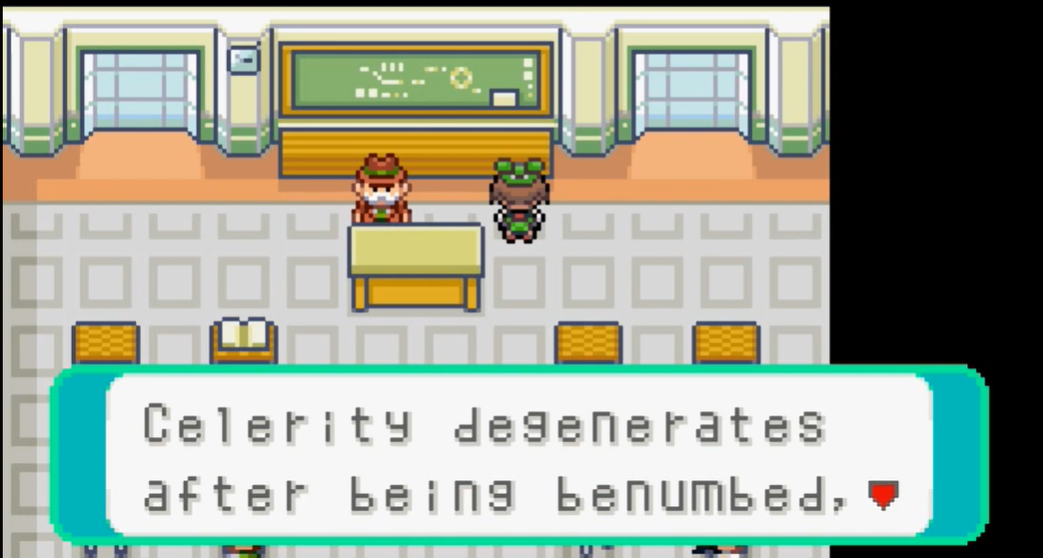

In [13]:
from IPython.display import Image 
metadata={
    "jdh": {
        "module": "object",
        "object": {
            "type":"image",
            "source": [
                "Screenshot from a bootleg copy of Pokémon Emerald (A possible correct translation might read \"The 'Paralyze' effect reduces a Pokémon's speed\""
            ]
        }
    }
}
display(Image("media/bootleg.png"), metadata=metadata)

Much of the existing academic literature that discusses the practise of ROM Hacking and/or fanslation is often framed around this legal context, as well as cultural and societal aspects of the practise (see, for example, <cite id="3gnbi"><a href="#zotero%7C23690838%2FNNZKYJRK">(Barnabé, 2018)</a></cite> and <cite id="ad9g5"><a href="#zotero%7C23690838%2FPT72WSJN">(Kirtz, 2018)</a></cite>). <cite id="vgofj"><a href="#zotero%7C23690838%2F7PTYDRD9">(Sánchez, 2009)</a></cite> provides a high-level overview of some techniques used by fan translators, but in this paper, we investigate at a deeper level through a practical case study of prototyping a reverse-engineered translation of a game, and review the challenges we faced. We review how the practice could be modernized and accellerated taking into account the last 20 years of innovation in computational advances.

While we will refer to other games, this research has been performed primarily on the Japanese visual novel game "ちょびっツ for GameboyAdvance -アタシだけのヒト–", or in roman characters – "Chobits: Atashi Dake no Hito" (Shortened to just "Chobits" for convenience for the rest of this paper). The methods in this work are independent of the actual title used.

### Background Information

The choice of *Chobits* for the case study within this paper is somewhat purposeful as it reflects both cultural and technical aspects of video game fan translation. First published as a manga in Japan in 2001 by Kodansha, *Chobits* was later translated and released in English by Tokyopop, which notes the original publication date <cite id="14wnk"><a href="#zotero%7C23690838%2FLCRQJ5I6">(CLAMP, 2002)</a></cite>, it was subsequently adapted into a 26-episode animated television series as well as three video games (the Game Boy Advance title examined in this paper, a PC game, and another on the Sony PlayStation 2) (<cite id="vecpj"><a href="#zotero%7C23690838%2FMGILIBEV">(<i>Chobits: Atashi Dake no Hito</i>, 2002)</a></cite>, <cite id="h5reu"><a href="#zotero%7C23690838%2FM44CMMKJ">(<i>Chobits: Chii Dake No Hito</i>, 2003)</a></cite>). The GBA game was released with a limited-edition GBA device (Figure \ref{fig:chobitspackage}). The game achieved commercial success in Japan and maintains cultural relevance, with the series continuing to be referenced in later media.

The series also had significant international reach --- The series has been licensed in North America, Taiwan, the Netherlands, Germany, Russia, and has been broadcast on Korean, Spanish, Portugese and Polish television networks. Recently, 20th anniversary editions of the manga were produced in English. Such widespread appeal suggests that an official translation of the game would have likely found at least a niche international audience.

As a work derived from a manga title, the fanslation of *Chobits* mirrors the efforts of fanslators in the subculture for decades, well before the GBA was even released. Anime and manga have a strong fan culture of sharing inaccessible media in the absence of licensing or localization companies. Tremblay argues that these sorts of efforts have created stronger interest in media and the genre as a whole, along with strengthened consumer investment into future products, much like how the Japanese doujinshi (unauthorized fan comics) are actively encouraged by their media's owners as it is seen as symbiotic rather than competitive \ref{FiT}. Indeed, several companies in media distribution have been created from systems such as these. A well-known example is Crunchyroll, now the largest dedicated anime streaming service, which was originally a fan-subtitle aggregation website before transitioning into a licensed platform (\cite{loo_crunchyroll_2008}). Another notable example is Manga Rock, a frontend for several illegal manga-hosting websites which transitioned into an official platform for manga, manwha and webtoons (\cite{mateo_mangarock_2020}). 

As noted in Section \ref{sec:intro}, existing academic work is predominantly concerned with these interesting legal and cultural scenarios, rather than the technical process of translation. As a visual novel, *Chobits* is a title with a lot of textual and visual content, which can be difficult to fit within the limited confines of the GBA device. Its translation is also crucial to the accessibility of the media, unlike other games, which one can enjoy without translation. \todo{write that better - mechanic-based games or something} Unlike anime or manga translation, which requires translation skills and some level of competency with image editing and subtitling software, translating this game perfectly would require an advanced programming skillset with an ability to reverse engineer and understand embedded devices. This high barrier to entry has historically limited the number of complete fanslations released each year. In Figure \ref{fig:releases}, a timeline of final releases of GBA games is shown, gathered from the romhacking.net community. The substantial increase in releases from 2019 to 2022 coincides with COVID-19 movement restrictions, which likely contributed to increased participation in home-based hobbies.

| Language               | Total | Percentage (%) |
|------------------------|-------|----------------|
| English                | 710   | 76.84          |
| Japanese               | 326   | 35.28          |
| French                 | 97    | 10.5           |
| German                 | 97    | 10.5           |
| Spanish (Spain)        | 83    | 8.98           |
| Italian                | 80    | 8.66           |
| Dutch                  | 43    | 4.65           |
| Danish                 | 15    | 1.62           |
| Chinese (Simplified)   | 14    | 1.52           |
| Swedish                | 10    | 1.08           |
| Norwegian              | 9     | 0.97           |
| Portuguese (Portugal)  | 8     | 0.87           |
| English (UK)           | 7     | 0.76           |
| Finnish                | 6     | 0.65           |
| Portuguese (Brazil)    | 3     | 0.32           |
| Polish                 | 3     | 0.32           |
| Korean                 | 2     | 0.22           |
| Spanish (Mexico)       | 2     | 0.22           |
| Arabic                 | 1     | 0.11           |
| Chinese (Traditional)  | 1     | 0.11           |

The distribution of language data in games gathered from the IGDB website should be considered with additional context. As a community-maintained resource, the completeness and accuracy of data entries vary. More popular titles tend to be more comprehensively catalogued. Furthermore, the English language interface may introduce biases in the quality and quantity of contributions to English or English-translated titles, over other languages. It is also prone to contributor error. Consequently, this data should be treated as an approximate representation of language support on the GBA, rather than a definitive or objective distribution.

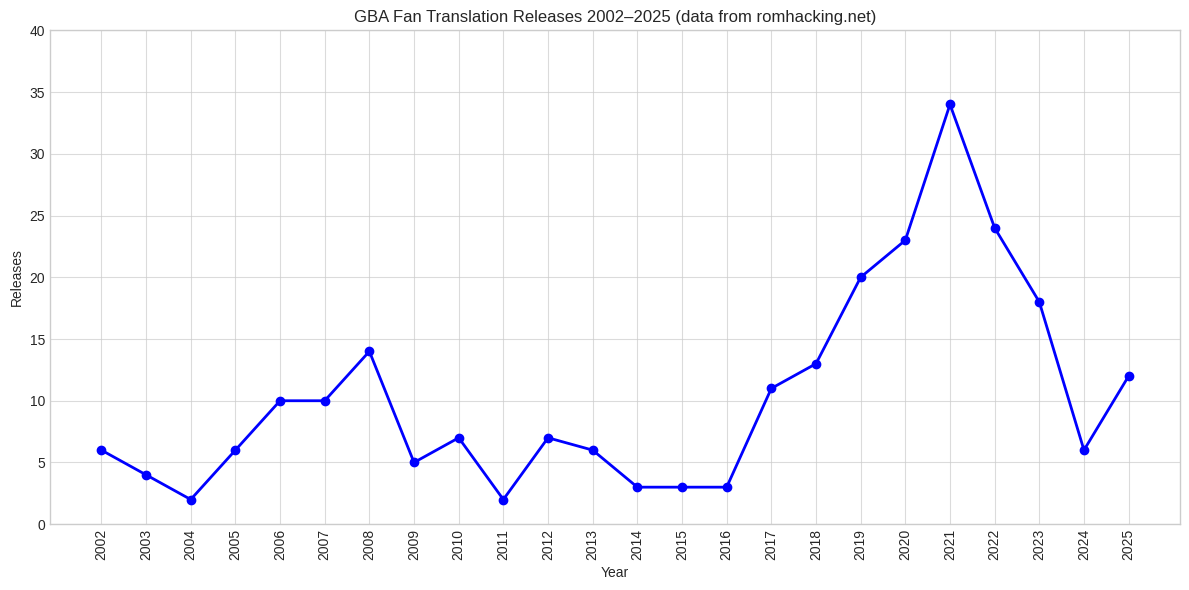

In [4]:
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
# 1. Prepare the data
data = [
    (2002,6), (2003,4), (2004,2), (2005,6), (2006,10), (2007,10),
    (2008,14), (2009,5), (2010,7), (2011,2), (2012,7), (2013,6),
    (2014,3), (2015,3), (2016,3), (2017,11), (2018,13), (2019,20),
    (2020,23), (2021,34), (2022,24), (2023,18), (2024,6), (2025,12)
]

years, releases = zip(*data)

# 2. Create the plot
plt.figure(figsize=(12, 6))
plt.plot(years, releases, color='blue', marker='o', linewidth=2, markersize=6)

# 3. Apply TikZ-like styling
plt.xlabel('Year')
plt.ylabel('Releases')
plt.title('GBA Fan Translation Releases 2002–2025 (data from romhacking.net)')

# Set axis limits and ticks to match your LaTeX code
plt.ylim(0, 40)
plt.xticks(years, rotation=90)
plt.grid(True, linestyle='-', alpha=0.7)

# 4. Display
plt.tight_layout()
plt.show()

Loading CSVs...
Normalizing & Aggregating...
Visualizing...


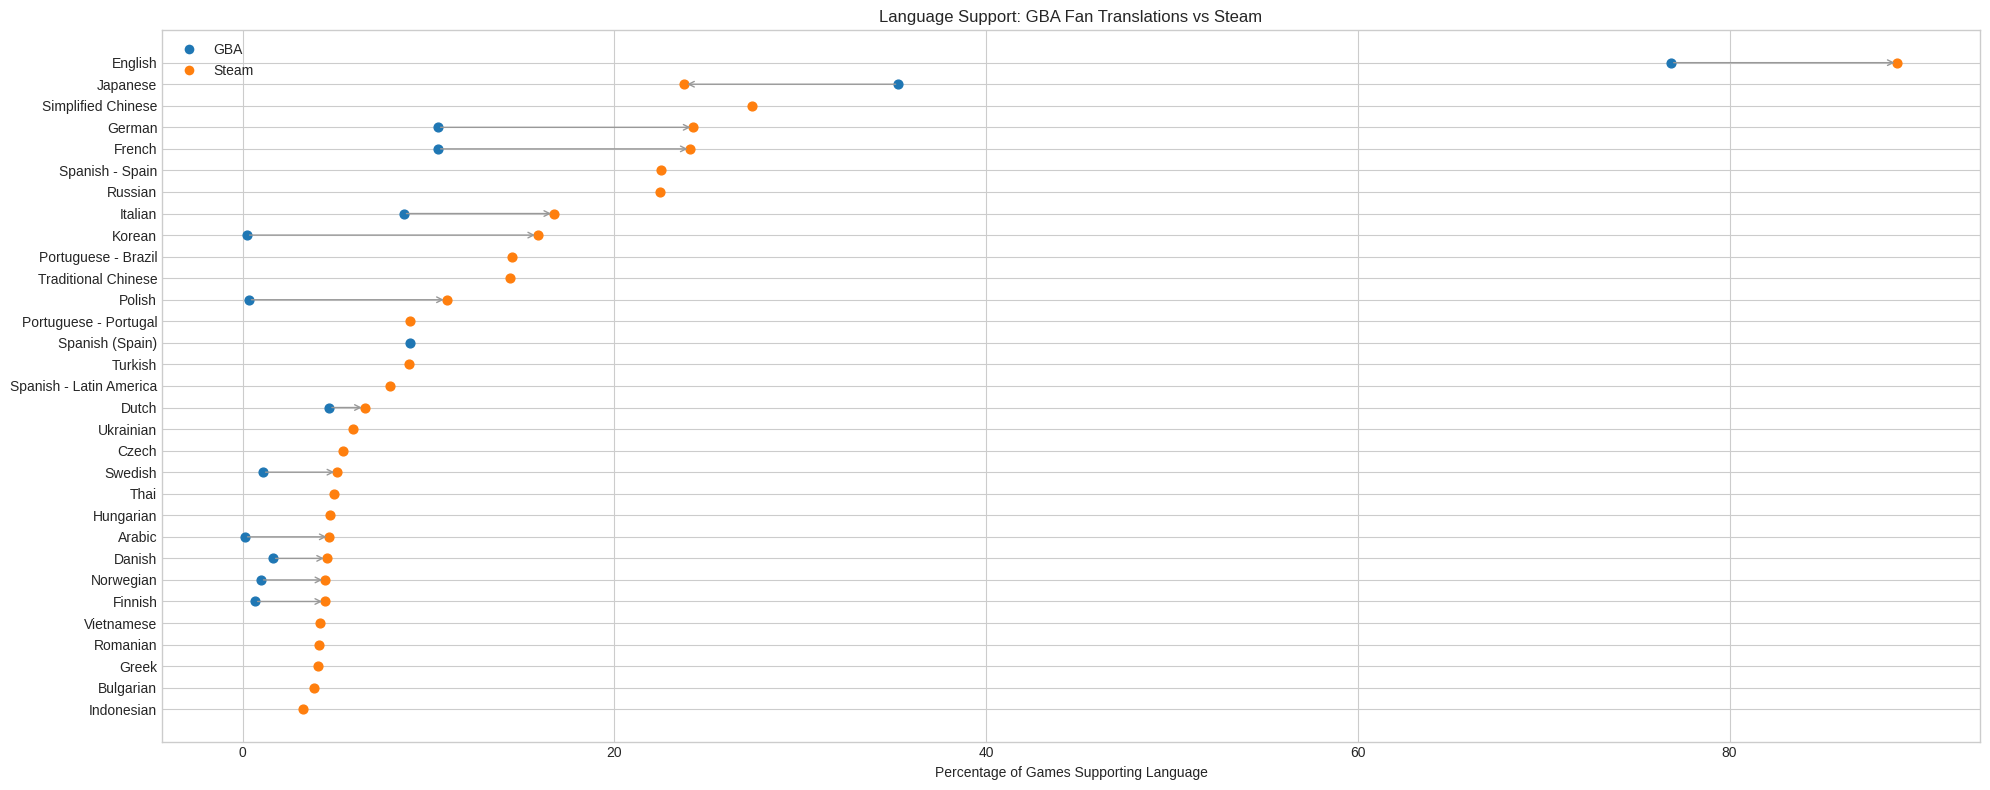

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import html

print("Loading CSVs...")

# Load GBA CSV
df_gba = pd.read_csv("https://raw.githubusercontent.com/ianfhunter/gba-fanslation-sample/refs/heads/main/gba_language_distribution.csv")

# Load Steam CSV (cleaned JSON converted to CSV)
df_steam = pd.read_csv("https://raw.githubusercontent.com/ianfhunter/gba-fanslation-sample/refs/heads/main/steam_games_clean.csv")

print("Normalizing & Aggregating...")

# --- Normalize column names ---
df_gba.columns = df_gba.columns.str.strip().str.lower().str.replace(" ", "_")
df_steam.columns = df_steam.columns.str.strip().str.lower().str.replace(" ", "_")

# Rename percentage columns
df_gba = df_gba.rename(columns={"percentage_(%)": "fan_pct"})
df_steam = df_steam.rename(columns={"steam_pct": "steam_pct"})
df_steam = df_steam.rename(columns={"supported_languages": "language"})

# Steam lists multiple languages in one cell (e.g. "English, Russian"); count each language per game
steam_expanded = df_steam.assign(
    language=df_steam["language"].fillna("").astype(str).str.split(",")
).explode("language", ignore_index=True)
steam_expanded["language"] = steam_expanded["language"].str.strip()
steam_expanded = steam_expanded[steam_expanded["language"].ne("")]

# --- Aggregate Steam data by language ---
steam_lang_pct = (
    steam_expanded.groupby("language")
    .size()
    .reset_index(name="steam_count")
)

total_steam_games = len(df_steam)
steam_lang_pct["steam_pct"] = steam_lang_pct["steam_count"] / total_steam_games * 100
steam_lang_pct = steam_lang_pct[["language", "steam_pct"]]

# --- Merge GBA and Steam ---
merged = pd.merge(df_gba, steam_lang_pct, on="language", how="outer")

# --- Sort by max value for readability ---
merged["sort_val"] = merged[["fan_pct", "steam_pct"]].max(axis=1)
merged = merged.sort_values("sort_val")

# Filtering out very low percentage languages
minimal_threshold = 2
merged = merged[(merged["fan_pct"].notna()) | (merged["steam_pct"].notna())]
merged = merged[
    (merged["fan_pct"] > minimal_threshold) | (merged["steam_pct"] > minimal_threshold)
]

print("Visualizing...")

# --- Colors ---
gba_color = "#1f77b4"
steam_color = "#ff7f0e"
line_color = "#999999"

# --- Plot ---
fig, ax = plt.subplots(figsize=(20, 8))
y_pos = np.arange(len(merged))

for i, row in enumerate(merged.itertuples(index=False)):
    x0 = row.fan_pct
    x1 = row.steam_pct

    # Arrow between both points when both are finite percentages
    if pd.notna(x0) and pd.notna(x1) and x0 != x1:
        ax.annotate(
            "",
            xy=(x1, i),
            xytext=(x0, i),
            arrowprops=dict(arrowstyle="->", color=line_color, lw=1),
        )

    # Dots where we have a value
    if pd.notna(x0):
        ax.scatter(x0, i, color=gba_color, s=40)
    if pd.notna(x1):
        ax.scatter(x1, i, color=steam_color, s=40)

# --- Labels ---
ax.set_yticks(y_pos)
ax.set_yticklabels(merged["language"])
ax.set_xlabel("Percentage of Games Supporting Language")
ax.set_title("Language Support: GBA Fan Translations vs Steam")

# --- Ensure lone points are visible ---
all_values = list(merged["fan_pct"].dropna()) + list(merged["steam_pct"].dropna())

xmin = min(all_values) if all_values else 0
xmax = max(all_values) if all_values else 1
padding = (xmax - xmin) * 0.05 if xmax != xmin else 1
ax.set_xlim(xmin - padding, xmax + padding)

# --- Legend ---
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='GBA',
           markerfacecolor=gba_color, markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Steam',
           markerfacecolor=steam_color, markersize=8)
]

ax.legend(handles=legend_elements)
plt.tight_layout()
plt.show()

## 